In [80]:
import os
import platform

if platform.system() == "Windows":
    os.environ["OMP_NUM_THREADS"] = "2"

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
shap.initjs()

import re
import ipywidgets as widgets

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    KFold
)

from sklearn import metrics
from sklearn.metrics import confusion_matrix, silhouette_score
import sklearn.metrics.cluster as smc
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder,
    MinMaxScaler
)
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn import tree
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_blobs
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
# HELPER

SEED = 66
random.seed(SEED)

from IPython.display import display, HTML
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer

f1_scorer = make_scorer(f1_score, pos_label="Yes")

In [2]:
data = []
chunksize = 10 ** 6

for chunk in pd.read_csv("datasets/GUIDE_Train.csv", chunksize=chunksize):
    data.append(chunk)

df = pd.concat(data, ignore_index=True)


C:\Users\limhe\AppData\Local\Temp\ipykernel_17340\2431449504.py:4: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv("datasets/GUIDE_Train.csv", chunksize=chunksize):
C:\Users\limhe\AppData\Local\Temp\ipykernel_17340\2431449504.py:4: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv("datasets/GUIDE_Train.csv", chunksize=chunksize):
C:\Users\limhe\AppData\Local\Temp\ipykernel_17340\2431449504.py:4: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv("datasets/GUIDE_Train.csv", chunksize=chunksize):
C:\Users\limhe\AppData\Local\Temp\ipykernel_17340\2431449504.py:4: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv("datasets/GUIDE_Train.csv", chunksize=chunksize):
C:\Users\limhe\AppDa

In [3]:
sample = df.sample(n=100000, random_state=SEED)
sample.shape

(100000, 45)

In [4]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 5717399 to 2040742
Data columns (total 45 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Id                  100000 non-null  int64  
 1   OrgId               100000 non-null  int64  
 2   IncidentId          100000 non-null  int64  
 3   AlertId             100000 non-null  int64  
 4   Timestamp           100000 non-null  object 
 5   DetectorId          100000 non-null  int64  
 6   AlertTitle          100000 non-null  int64  
 7   Category            100000 non-null  object 
 8   MitreTechniques     42412 non-null   object 
 9   IncidentGrade       99456 non-null   object 
 10  ActionGrouped       598 non-null     object 
 11  ActionGranular      598 non-null     object 
 12  EntityType          100000 non-null  object 
 13  EvidenceRole        100000 non-null  object 
 14  DeviceId            100000 non-null  int64  
 15  Sha256              100000 non-n

In [5]:
sample.head()

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
5717399,317827584458,69,82313,238761,2024-06-11T16:35:21.000Z,6,5,InitialAccess,T1566,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NoThreatsFound,242,1445,10630
9369628,730144441619,252,7048,143763,2024-06-06T08:47:57.000Z,114,92,CredentialAccess,T1003;T1005;T1119;T1539;T1550.004;T1552.001;T1...,FalsePositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
3320377,1425929146232,208,6474,141809,2024-06-12T13:52:12.000Z,747,1025,CredentialAccess,T1003;T1552.001,BenignPositive,...,NaN,NaN,0,0,NaN,Suspicious,Suspicious,242,1445,10630
5790759,1357209668998,692,246900,1055589,2024-06-08T17:07:47.000Z,0,0,InitialAccess,T1078;T1078.004,FalsePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
6948032,240518171233,40,154429,156821,2024-06-13T13:09:52.000Z,1,1,InitialAccess,T1566.002,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,Malicious,242,1445,10630


In [6]:
sample.isnull().sum()

Id                        0
OrgId                     0
IncidentId                0
AlertId                   0
Timestamp                 0
DetectorId                0
AlertTitle                0
Category                  0
MitreTechniques       57588
IncidentGrade           544
ActionGrouped         99402
ActionGranular        99402
EntityType                0
EvidenceRole              0
DeviceId                  0
Sha256                    0
IpAddress                 0
Url                       0
AccountSid                0
AccountUpn                0
AccountObjectId           0
AccountName               0
DeviceName                0
NetworkMessageId          0
EmailClusterId        99017
RegistryKey               0
RegistryValueName         0
RegistryValueData         0
ApplicationId             0
ApplicationName           0
OAuthApplicationId        0
ThreatFamily          99194
FileName                  0
FolderPath                0
ResourceIdName            0
ResourceType        

In [7]:
sample = sample.drop(["ActionGrouped"], axis=1)
sample = sample.drop(["ActionGranular"], axis=1)
sample = sample.drop(["EmailClusterId"], axis=1)
sample = sample.drop(["ThreatFamily"], axis=1)
sample = sample.drop(["ResourceType"], axis=1)
sample = sample.drop(["Roles"], axis=1)
sample = sample.drop(["AntispamDirection"], axis=1)

sample = sample.drop(columns=["Id", "OrgId", "IncidentId", "AlertId"], axis=1)


In [8]:
column_list = sample.columns.values.tolist()

print("Number of Unique Values:")
for column in column_list: 
    print(f"{column}: {sample[column].nunique()}")

# sample[""].nunique()

Number of Unique Values:
Timestamp: 79237
DetectorId: 2525
AlertTitle: 11821
Category: 18
MitreTechniques: 516
IncidentGrade: 3
EntityType: 22
EvidenceRole: 2
DeviceId: 3084
Sha256: 3965
IpAddress: 13642
Url: 4331
AccountSid: 18113
AccountUpn: 28119
AccountObjectId: 17980
AccountName: 18973
DeviceName: 5170
NetworkMessageId: 11484
RegistryKey: 66
RegistryValueName: 27
RegistryValueData: 36
ApplicationId: 62
ApplicationName: 98
OAuthApplicationId: 26
FileName: 6124
FolderPath: 3460
ResourceIdName: 75
OSFamily: 4
OSVersion: 14
SuspicionLevel: 2
LastVerdict: 4
CountryCode: 104
State: 354
City: 806


In [9]:
sample["LastVerdict"].unique()

array(['NoThreatsFound', 'Suspicious', nan, 'Malicious',
       'DomainPII_9207384283ce115db5a590dd9ca5de21e5e99df2'], dtype=object)

In [10]:
sample["LastVerdict"].value_counts()

LastVerdict
Suspicious                                            14809
Malicious                                              4529
NoThreatsFound                                         4147
DomainPII_9207384283ce115db5a590dd9ca5de21e5e99df2        1
Name: count, dtype: int64

In [11]:
sample = sample[sample["LastVerdict"] != "DomainPII_9207384283ce115db5a590dd9ca5de21e5e99df2"]
sample["LastVerdict"] = sample["LastVerdict"].fillna("Unknown")

In [12]:
sample["LastVerdict"].unique()

array(['NoThreatsFound', 'Suspicious', 'Unknown', 'Malicious'],
      dtype=object)

In [13]:
sample["Timestamp"] = pd.to_datetime(sample["Timestamp"])

sample["Second"] = sample["Timestamp"].dt.second
sample["Minute"] = sample["Timestamp"].dt.minute
sample["Hour"] = sample["Timestamp"].dt.hour
sample["Day"] = sample["Timestamp"].dt.day
sample["DayName"] = sample["Timestamp"].dt.day_name()
sample["Month"] = sample["Timestamp"].dt.month
sample["Year"] = sample["Timestamp"].dt.year

sample = sample.drop(["Timestamp"], axis=1)

In [14]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99999 entries, 5717399 to 2040742
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   DetectorId          99999 non-null  int64 
 1   AlertTitle          99999 non-null  int64 
 2   Category            99999 non-null  object
 3   MitreTechniques     42412 non-null  object
 4   IncidentGrade       99455 non-null  object
 5   EntityType          99999 non-null  object
 6   EvidenceRole        99999 non-null  object
 7   DeviceId            99999 non-null  int64 
 8   Sha256              99999 non-null  int64 
 9   IpAddress           99999 non-null  int64 
 10  Url                 99999 non-null  int64 
 11  AccountSid          99999 non-null  int64 
 12  AccountUpn          99999 non-null  int64 
 13  AccountObjectId     99999 non-null  int64 
 14  AccountName         99999 non-null  int64 
 15  DeviceName          99999 non-null  int64 
 16  NetworkMessageId   

In [15]:
le = LabelEncoder()
sample["target"] = le.fit_transform(sample["LastVerdict"])
sample = sample.drop(["LastVerdict"], axis=1)

y = sample["target"]
x = sample.drop(["target"], axis=1)

train, test, target, target_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=SEED)

categorical_features = ["Category", "MitreTechniques", "IncidentGrade", "EntityType", "EvidenceRole", "SuspicionLevel", "DayName"]

numerical_features = train.drop(columns=categorical_features).columns.tolist()

num_pipeline= Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scalar", MinMaxScaler())

])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

full_pipeline.fit(train, target)


C:\Users\limhe\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [17:07:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   MinMaxScaler())]),
                                                  ['DetectorId', 'AlertTitle',
                                                   'DeviceId', 'Sha256',
                                                   'IpAddress', 'Url',
                                                   'AccountSid', 'AccountUpn',
                                                   'AccountObjectId',
                                                   'AccountName', 'DeviceName',
                                                   'NetworkMessageId',
                                                   'RegistryKey',
                                                   'RegistryValueName',
                                                   'RegistryValueDat...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [39]:
feature_names = full_pipeline.named_steps['preprocessing'].get_feature_names_out()

clean_feature_names = [
    re.sub(r"^(num|cat)__", "", name) for name in feature_names
]


In [16]:
prediction = full_pipeline.predict(test)
print(f"Accuracy: {accuracy_score(target_test, prediction)}")

Accuracy: 0.9448


In [17]:
full_pipeline.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'classifier', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'preprocessing__verbose_feature_names_out', 'preprocessing__num', 'preprocessing__cat', 'preprocessing__num__memory', 'preprocessing__num__steps', 'preprocessing__num__transform_input', 'preprocessing__num__verbose', 'preprocessing__num__imputer', 'preprocessing__num__scalar', 'preprocessing__num__imputer__add_indicator', 'preprocessing__num__imputer__copy', 'preprocessing__num__imputer__fill_value', 'preprocessing__num__imputer__keep_empty_features', 'preprocessing__num__imputer__missing_values', 'preprocessing__num__imputer__strategy', 'preprocessing__num__scalar__clip', 'preprocessing__num__scalar__copy', 'preprocessing__num__scalar__feature_range', 'preprocessing__cat__m

In [18]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    estimator=full_pipeline, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1, 
    verbose=2, 
    refit=True, 
    return_train_score=True
)

grid.fit(train, target)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\limhe\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [17:17:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scalar',
                                                                                          MinMaxScaler())]),
                                                                         ['DetectorId',
                                                                          'AlertTitle',
                                                                          'DeviceId',
                                                                          'Sha256',
                                                                          'IpAddress',
                                                                          'Url',
                                                                          'AccountSid',
                                                                          'AccountUpn',
                                                                          'AccountObjectId',
                                                                          'AccountName',
                                                                          'DeviceName',
                                                                          'NetworkMessageId',
                                                                          'RegistryKey',
                                                                          'Registry...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.05, 0.1],
                         'classifier__max_depth': [3, 5, 7],
                         'classifier__n_estimators': [100, 200]},
             return_train_score=True, scoring='accuracy', verbose=2)

In [19]:
best_model = grid.best_estimator_
best_score = grid.best_score_

print("Best Model:", best_model)
print("Best Score:", best_score)

Best Model: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   MinMaxScaler())]),
                                                  ['DetectorId', 'AlertTitle',
                                                   'DeviceId', 'Sha256',
                                                   'IpAddress', 'Url',
                                                   'AccountSid', 'AccountUpn',
                                                   'AccountObjectId',
                                                   'AccountName', 'DeviceName',
                                                   'NetworkMessageId',
                                                

In [20]:
best_predict1 = best_model.predict(test)
print("Accuracy:", accuracy_score(target_test, best_predict1))

Accuracy: 0.9444


In [22]:
xbgoost_model = best_model.named_steps["classifier"]

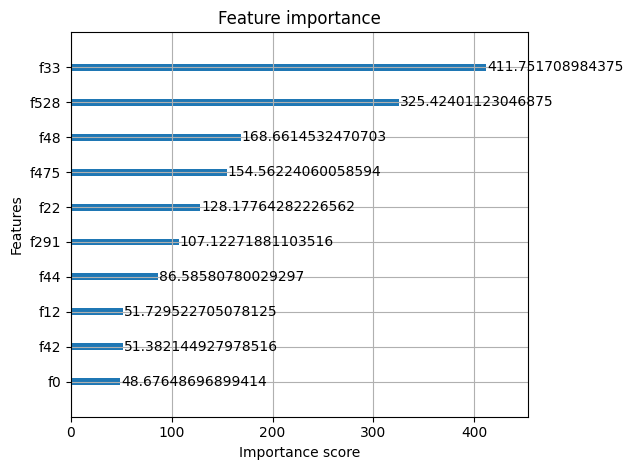

In [26]:
plot_importance(xbgoost_model, importance_type="gain", max_num_features=10)
plt.tight_layout()
plt.show()

In [ ]:
importances = xbgoost_model.get_booster().get_score(importance_type='gain')

mapped_importances = {
    clean_feature_names[int(f[1:])]: score for f, score in importances.items()
}

importances_df = pd.DataFrame(mapped_importances.items(), columns=['Features', 'Importance'])
importances_df = importances_df.sort_values(by='Importance', ascending=False)


pd.set_option('display.max_rows', None)
print(importances_df)

                                              Features  Importance
27                          Category_CommandAndControl  411.751709
122                                 EntityType_Process  325.424011
40                         Category_SuspiciousActivity  168.661453
107                          MitreTechniques_T1566.002  154.562241
19                                           OSVersion  128.177643
76                     MitreTechniques_T1078;T1078.004  107.122719
37                                    Category_Malware   86.585808
12                                         RegistryKey   51.729523
35                              Category_InitialAccess   51.382145
0                                           DetectorId   48.676487
119                             EntityType_MailCluster   48.527138
116                                    EntityType_File   47.909939
106                          MitreTechniques_T1566.001   44.992996
18                                            OSFamily   41.07

['Malicious' 'NoThreatsFound' 'Suspicious' 'Unknown']


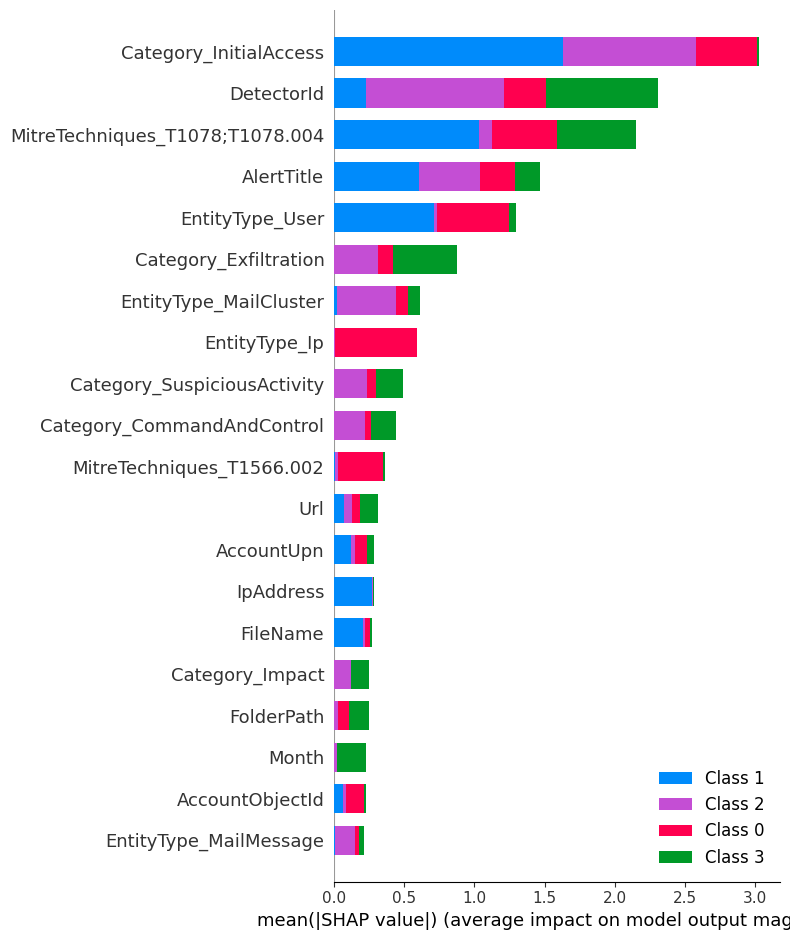

In [43]:
test_transformed = full_pipeline.named_steps["preprocessing"].transform(test)

explainer = shap.Explainer(xbgoost_model)
shap_values = explainer(test_transformed)

print(le.classes_)
shap.summary_plot(shap_values, features=test_transformed, feature_names=clean_feature_names)

In [60]:
for i in range(4):
    display(shap.plots.force(shap_values[0, :, i]))


In [ ]:
force_plot = shap.plots.force(shap_values[0, :, 2])
shap.save_html("shap_force_plot.html", force_plot)

In [83]:
class_map = {
    'Malicious': 0,
    'NoThreatsFound': 1,
    'Suspicious': 2,
    'Unknown': 3
}


def show_shap(class_idx, sample_idx):
    class_index = class_map[class_idx]
    sample_row_df = pd.DataFrame([test_transformed[sample_idx]], columns=clean_feature_names)

    display(HTML(f"""
        <div style="overflow-x: auto; white-space: nowrap; border:1px solid #ccc; padding: 10px;">
        {sample_row_df.to_html(index=False)}
        </div>
    """))
    display(shap.plots.force(shap_values[sample_idx, :, class_index], matplotlib=True))

sample_slider = widgets.IntSlider(min=0, max=100, step=1, description="Sample:")
class_dropdown = widgets.Dropdown(options=list(class_map.keys()), description="Class:")

ui = widgets.VBox([sample_slider, class_dropdown])
output = widgets.interactive_output(show_shap, {"class_idx": class_dropdown, "sample_idx":  sample_slider})

display(ui, output)

Output()